# *Baseline shortlist*: robustez fold-level y solape de etiquetas (Exp1)

Complemento de `01_evidencia_shortlist_baseline.ipynb` sobre la campaña `20260502T120458Z` (`5` símbolos × `3` métodos, modo confirmatory). Solo lectura: consume artefactos ya persistidos y escribe tablas y figuras en el mismo manifest que el notebook `01` (`reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/`).

**Par de lectura:** `01_evidencia_shortlist_baseline.ipynb` (evidencia ejecutiva Exp1) -> este notebook (robustez fold-level y solape de etiquetas).

| Bloque | Pregunta |
| --- | --- |
| **A** | ¿Es estable el Sharpe **por fold** según la regla usada para coronar al campeón? |
| **B** | ¿Coinciden clases y pesos cuando dos métodos de etiquetado comparten el mismo `event_start_ts`? |

El detalle metodológico (fuentes, definiciones de campeón, parejas TB/TS/FH y notas sobre `metrics_fold.json`) está en los encabezados de cada sección más abajo.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)


def locate_repo_root(start: Path | None = None) -> Path:
    root = (start or Path.cwd()).resolve()
    while root != root.parent and not (root / "src").is_dir():
        root = root.parent
    if not (root / "src").is_dir():
        raise FileNotFoundError("No se encontró la raíz del repositorio desde el directorio actual.")
    return root


ROOT = locate_repo_root()
CAMPAIGN_SUFFIX = "20260502T120458Z"
CAMPAIGN_STAMP = CAMPAIGN_SUFFIX
REPORT_ROOT = ROOT / "reports" / "validation" / "experiments"
EVIDENCE_DIR = REPORT_ROOT / f"baseline_shortlist_{CAMPAIGN_SUFFIX}_evidence"
TABLE_DIR = EVIDENCE_DIR / "tables"
FIG_DISP = EVIDENCE_DIR / "figures" / "fold_sharpe_dispersion"
FIG_OVER = EVIDENCE_DIR / "figures" / "label_overlap"
for directory in (TABLE_DIR, FIG_DISP, FIG_OVER):
    directory.mkdir(parents=True, exist_ok=True)
for sub in ["boxplots", "heatmaps", "lineplots"]:
    (FIG_DISP / sub).mkdir(parents=True, exist_ok=True)
for sub in ["class_distribution", "weights", "agreement"]:
    (FIG_OVER / sub).mkdir(parents=True, exist_ok=True)

DATA_PROC = ROOT / "data" / "03_processed"
EXP_ROOT = REPORT_ROOT
TB_LABELS_ROOT = DATA_PROC / "exp1_triple_barrier_cusum_return_sign" / "targets"
STD_LABELS_ROOT = DATA_PROC / "targets"

SYMBOLS = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT"]
METHODS = ["triple_barrier", "trend_scanning", "fixed_horizon"]
FAMILIES = ["no_skill", "xgboost", "lstm", "residual_hybrid", "voting"]

COLUMNAS_ES = {
    "symbol": "simbolo",
    "method": "metodo",
    "method_a": "metodo_a",
    "method_b": "metodo_b",
    "definition": "definicion",
    "definition_a": "definicion_a",
    "definition_b": "definicion_b",
    "family": "familia",
    "family_a": "familia_a",
    "family_b": "familia_b",
    "status": "estado",
    "verdict": "veredicto",
    "fold": "fold",
    "n_folds_used": "n_folds_usados",
    "n_pairs": "n_pares",
    "sharpe_median": "sharpe_mediana",
    "sharpe_iqr": "sharpe_iqr",
    "sharpe_mean": "sharpe_media",
    "sharpe_std": "sharpe_desv_estandar",
    "pct_folds_sharpe_pos": "pct_folds_sharpe_positivo",
    "total_return_median": "retorno_total_mediano",
    "mdd_median": "mdd_mediano",
    "median_diff_a_minus_b": "diff_mediana_a_menos_b",
    "mean_diff_a_minus_b": "diff_media_a_menos_b",
    "pct_pairs_a_gt_b": "pct_pares_a_mayor_b",
    "statistic": "estadistico",
    "p_value": "p_valor",
    "n_full_a": "n_total_a",
    "n_full_b": "n_total_b",
    "n_overlap": "n_solape",
    "overlap_pct_of_a": "pct_solape_sobre_a",
    "overlap_pct_of_b": "pct_solape_sobre_b",
    "agreement_pct": "pct_acuerdo",
    "weighted_agreement_avg_uniqueness": "acuerdo_ponderado_avg_uniqueness",
    "dist_full_a": "dist_total_a",
    "dist_full_b": "dist_total_b",
    "dist_overlap_a": "dist_solape_a",
    "dist_overlap_b": "dist_solape_b",
}
for clase in ("-1", "0", "1"):
    for prefijo_en, prefijo_es in (
        ("dist_full_a", "dist_total_a"),
        ("dist_full_b", "dist_total_b"),
        ("dist_overlap_a", "dist_solape_a"),
        ("dist_overlap_b", "dist_solape_b"),
    ):
        COLUMNAS_ES[f"{prefijo_en}_{clase}"] = f"{prefijo_es}_{clase}"
for col_en in ("avg_uniqueness", "sample_weight_overlap", "concurrency"):
    for tag in ("a", "b"):
        COLUMNAS_ES[f"{col_en}_mean_{tag}_overlap"] = f"{col_en}_media_solape_{tag}"
        COLUMNAS_ES[f"{col_en}_p50_{tag}_overlap"] = f"{col_en}_p50_solape_{tag}"

print(f"RAIZ={ROOT}")
print(f"DIR_EVIDENCIA={EVIDENCE_DIR}")
print(f"Figuras de dispersión por fold -> {FIG_DISP}")
print(f"Figuras de solape de etiquetas -> {FIG_OVER}")


RAIZ=/app
DIR_EVIDENCIA=/app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence
Figuras de dispersión por fold -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/fold_sharpe_dispersion
Figuras de solape de etiquetas -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/label_overlap


In [2]:
def study_dir(symbol: str, method: str) -> Path:
    return EXP_ROOT / f"baseline_shortlist_{symbol.lower()}_{method}_{CAMPAIGN_STAMP}__ffd_on"


def summary_path(symbol: str, method: str) -> Path:
    return EXP_ROOT / f"baseline_shortlist_{symbol.lower()}_{method}_{CAMPAIGN_STAMP}" / "budgeted_search_summary.json"


def load_summary(symbol: str, method: str) -> dict:
    return json.loads(summary_path(symbol, method).read_text(encoding="utf-8"))


def best_definitions(summary: dict) -> dict:
    sr = summary.get("search_result", {})
    best_explor_family = (sr.get("best_config") or {}).get("family")
    rank = sr.get("confirmatory_ranking_rows", []) or []
    top1_family = rank[0].get("family") if len(rank) > 0 else None
    top2_family = rank[1].get("family") if len(rank) > 1 else None
    best_conf_id = sr.get("best_confirmatory_trial_id")
    best_conf_family = None
    for r in rank:
        if r.get("trial_id") == best_conf_id:
            best_conf_family = r.get("family")
            break
    return {
        "best_exploratory": best_explor_family,
        "confirmatory_top1": top1_family,
        "confirmatory_top2": top2_family,
        "best_confirmatory": best_conf_family,
    }


def list_fold_dirs(symbol: str, method: str) -> list[Path]:
    sd = study_dir(symbol, method)
    folds = sorted((sd / "folds").glob("fold_*")) if sd.exists() else []
    return folds


def load_fold_metrics(symbol: str, method: str, family: str, fold_dir: Path) -> dict | None:
    p = fold_dir / "models" / family / "metrics_fold.json"
    if not p.exists():
        return None
    try:
        return json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        return None


def fold_id_from_dir(p: Path) -> int:
    m = re.search(r"fold_(\d+)$", p.name)
    return int(m.group(1)) if m else -1


defs_rows = []
for s in SYMBOLS:
    for m in METHODS:
        sm = load_summary(s, m)
        d = best_definitions(sm)
        defs_rows.append({"symbol": s, "method": m, **d, "n_folds": len(list_fold_dirs(s, m))})
definitions_df = pd.DataFrame(defs_rows)
definitions_df


,symbol,method,best_exploratory,confirmatory_top1,confirmatory_top2,best_confirmatory,n_folds
0,BTCUSDT,triple_barrier,no_skill,no_skill,no_skill,no_skill,27
1,BTCUSDT,trend_scanning,lstm,xgboost,lstm,xgboost,97
2,BTCUSDT,fixed_horizon,residual_hybrid,residual_hybrid,residual_hybrid,residual_hybrid,97
3,ETHUSDT,triple_barrier,xgboost,xgboost,residual_hybrid,xgboost,28
4,ETHUSDT,trend_scanning,xgboost,no_skill,xgboost,no_skill,97
5,ETHUSDT,fixed_horizon,xgboost,xgboost,residual_hybrid,xgboost,97
6,BNBUSDT,triple_barrier,residual_hybrid,residual_hybrid,residual_hybrid,residual_hybrid,29
7,BNBUSDT,trend_scanning,residual_hybrid,residual_hybrid,residual_hybrid,residual_hybrid,95
8,BNBUSDT,fixed_horizon,residual_hybrid,residual_hybrid,residual_hybrid,residual_hybrid,95
9,XRPUSDT,triple_barrier,residual_hybrid,residual_hybrid,xgboost,residual_hybrid,26


## A. Dispersión de Sharpe por fold

Fuente: `metrics_fold.json` en `baseline_shortlist_<symbol>_<method>_<stamp>__ffd_on/folds/fold_NNN/models/<family>/`. Métricas: `strategy_sharpe`, `strategy_sortino`, `strategy_total_return`, `strategy_max_drawdown` (y `n_obs` si existe).

Cuatro reglas de campeón desde `budgeted_search_summary.json`: `best_exploratory`, `confirmatory_top1`, `confirmatory_top2`, `best_confirmatory` (mapeo en `best_definitions`).

> Nota: un artefacto por (fold, family), no por trial; si dos reglas eligen la misma family, comparten métricas.

A continuación se construye el DataFrame long por fold y se resume la dispersión, incluido Wilcoxon pareado cuando dos reglas apuntan a familias distintas.


In [3]:
METRIC_KEYS = ("strategy_sharpe", "strategy_sortino", "strategy_total_return", "strategy_max_drawdown", "hit_rate", "n_obs")


def extract_metrics(metrics_doc: dict) -> dict:
    em = metrics_doc.get("economic_metrics") or {}
    out = {}
    for k in METRIC_KEYS:
        if k in em:
            out[k] = em.get(k)
        else:
            out[k] = metrics_doc.get(k)
    return out


def role_label(family: str, defs: dict) -> str:
    roles = []
    for role_name, fam in defs.items():
        if fam == family:
            roles.append(role_name)
    return ",".join(roles) if roles else ""


rows = []
for s in SYMBOLS:
    for m in METHODS:
        defs = best_definitions(load_summary(s, m))
        for fdir in list_fold_dirs(s, m):
            fid = fold_id_from_dir(fdir)
            for fam in FAMILIES:
                doc = load_fold_metrics(s, m, fam, fdir)
                if not doc:
                    continue
                metrics = extract_metrics(doc)
                rows.append({
                    "symbol": s,
                    "method": m,
                    "family": fam,
                    "fold": fid,
                    "family_role": role_label(fam, defs),
                    **metrics,
                })

fold_df = pd.DataFrame(rows)
print("filas:", len(fold_df), "celdas:", fold_df.groupby(["symbol", "method"]).ngroups)
fold_df.head()


filas: 4781 celdas: 15


,symbol,method,family,fold,family_role,strategy_sharpe,strategy_sortino,strategy_total_return,strategy_max_drawdown,hit_rate,n_obs
0,BTCUSDT,triple_barrier,no_skill,0,"best_exploratory,confirmatory_top1,confirmator...",0.113153,0.178763,0.449064,-0.217162,0.600000,180
1,BTCUSDT,triple_barrier,xgboost,0,,0.090401,0.148268,0.359597,-0.295474,0.561111,180
2,BTCUSDT,triple_barrier,lstm,0,,0.062593,0.102529,0.249350,-0.217162,0.533333,180
3,BTCUSDT,triple_barrier,residual_hybrid,0,,0.030889,0.055215,0.123313,-0.229648,0.500000,180
4,BTCUSDT,triple_barrier,voting,0,,0.100802,0.176228,0.400572,-0.176250,0.561111,180


### A.1 Resumen de dispersión por (symbol, method, definición)

Por cada celda y cada definición del "mejor trial" se calcula sobre los folds:

- `n_folds_used`, `sharpe_median`, `sharpe_iqr`, `sharpe_mean`, `sharpe_std`,
  `pct_folds_sharpe_pos`, `total_return_median`, `mdd_median`.


In [4]:
def summarize_subset(sub: pd.DataFrame) -> dict:
    s = sub["strategy_sharpe"].dropna()
    if s.empty:
        return {
            "n_folds_used": 0, "sharpe_median": np.nan, "sharpe_iqr": np.nan,
            "sharpe_mean": np.nan, "sharpe_std": np.nan,
            "pct_folds_sharpe_pos": np.nan, "total_return_median": np.nan,
            "mdd_median": np.nan,
        }
    q1, q3 = float(s.quantile(0.25)), float(s.quantile(0.75))
    return {
        "n_folds_used": int(len(s)),
        "sharpe_median": round(float(s.median()), 4),
        "sharpe_iqr": round(q3 - q1, 4),
        "sharpe_mean": round(float(s.mean()), 4),
        "sharpe_std": round(float(s.std(ddof=1)) if len(s) > 1 else 0.0, 4),
        "pct_folds_sharpe_pos": round(float((s > 0).mean()), 4),
        "total_return_median": round(float(sub["strategy_total_return"].dropna().median()), 4) if "strategy_total_return" in sub else np.nan,
        "mdd_median": round(float(sub["strategy_max_drawdown"].dropna().median()), 4) if "strategy_max_drawdown" in sub else np.nan,
    }


def_rows = []
for s in SYMBOLS:
    for m in METHODS:
        defs = best_definitions(load_summary(s, m))
        for role, fam in defs.items():
            if not fam:
                continue
            sub = fold_df[(fold_df.symbol == s) & (fold_df.method == m) & (fold_df.family == fam)]
            stats = summarize_subset(sub)
            def_rows.append({"symbol": s, "method": m, "definition": role, "family": fam, **stats})

definition_summary_df = pd.DataFrame(def_rows)
definition_summary_df.sort_values(["method", "symbol", "definition"]).reset_index(drop=True).rename(columns=COLUMNAS_ES)


,simbolo,metodo,definicion,familia,n_folds_usados,sharpe_mediana,sharpe_iqr,sharpe_media,sharpe_desv_estandar,pct_folds_sharpe_positivo,retorno_total_mediano,mdd_mediano
0,BNBUSDT,fixed_horizon,best_confirmatory,residual_hybrid,95,0.0286,0.1386,0.0193,0.1390,0.5789,0.1639,-0.5575
1,BNBUSDT,fixed_horizon,best_exploratory,residual_hybrid,95,0.0286,0.1386,0.0193,0.1390,0.5789,0.1639,-0.5575
2,BNBUSDT,fixed_horizon,confirmatory_top1,residual_hybrid,95,0.0286,0.1386,0.0193,0.1390,0.5789,0.1639,-0.5575
3,BNBUSDT,fixed_horizon,confirmatory_top2,residual_hybrid,95,0.0286,0.1386,0.0193,0.1390,0.5789,0.1639,-0.5575
4,BTCUSDT,fixed_horizon,best_confirmatory,residual_hybrid,97,-0.0010,0.2244,0.0143,0.1610,0.4742,-0.0058,-0.5196
5,BTCUSDT,fixed_horizon,best_exploratory,residual_hybrid,97,-0.0010,0.2244,0.0143,0.1610,0.4742,-0.0058,-0.5196
6,BTCUSDT,fixed_horizon,confirmatory_top1,residual_hybrid,97,-0.0010,0.2244,0.0143,0.1610,0.4742,-0.0058,-0.5196
7,BTCUSDT,fixed_horizon,confirmatory_top2,residual_hybrid,97,-0.0010,0.2244,0.0143,0.1610,0.4742,-0.0058,-0.5196
8,ETHUSDT,fixed_horizon,best_confirmatory,xgboost,97,0.0277,0.2272,0.0279,0.1585,0.5464,0.2208,-0.6129
9,ETHUSDT,fixed_horizon,best_exploratory,xgboost,97,0.0277,0.2272,0.0279,0.1585,0.5464,0.2208,-0.6129


### A.2 Boxplot de Sharpe por (method, definición)

Se agregan todos los símbolos por method y se representan en boxplots los Sharpes por fold de la
family que corresponde a cada definición. Permite ver si las definiciones convergen.


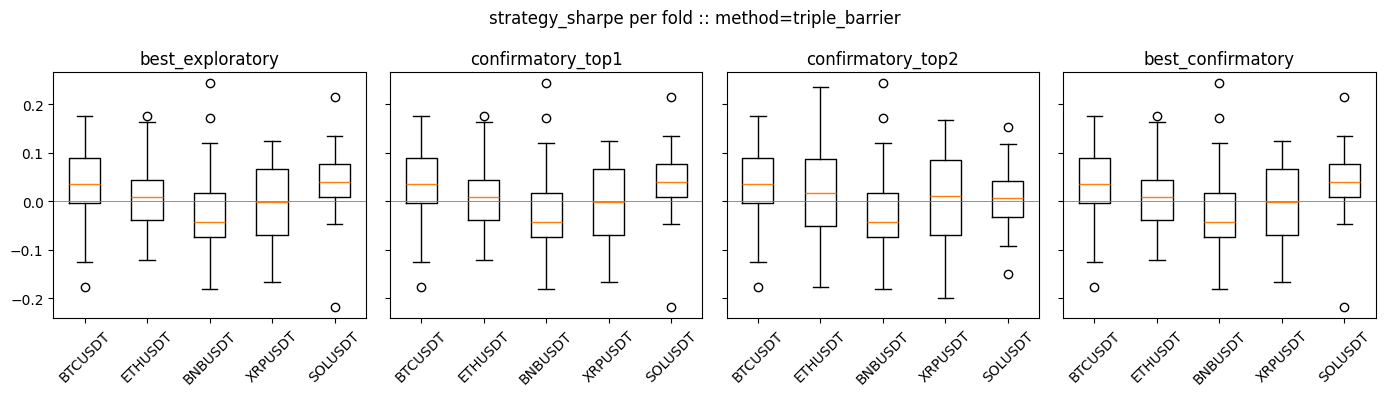

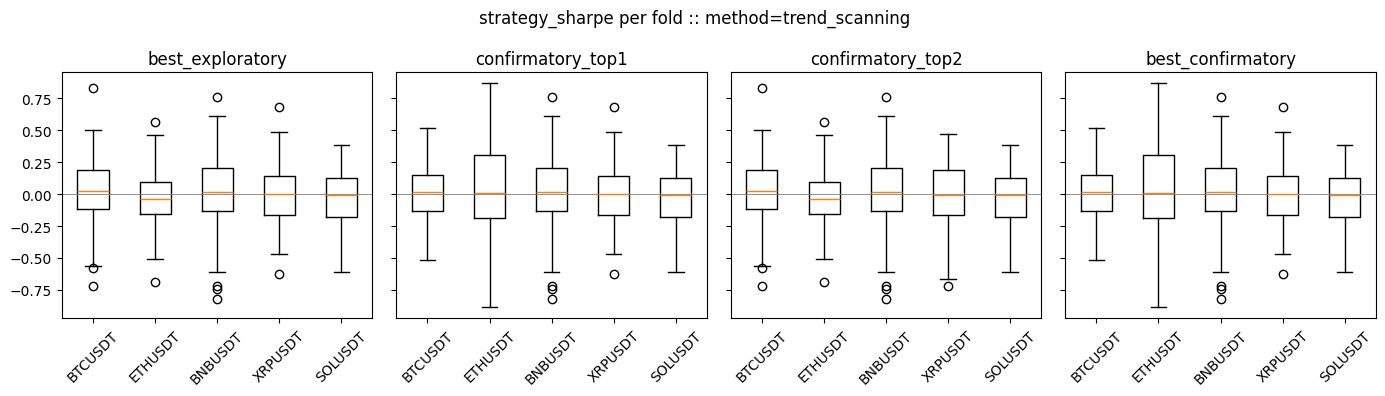

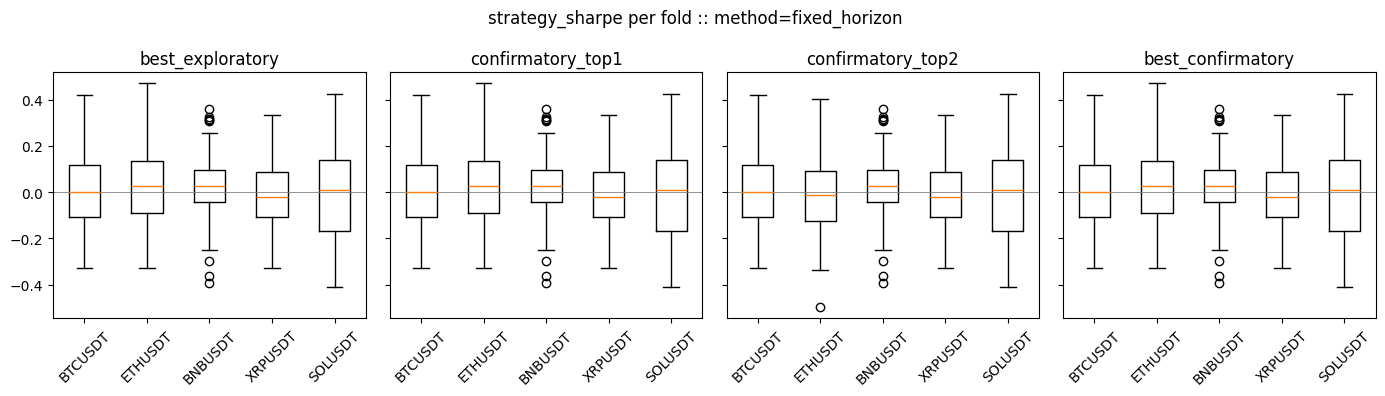

boxplots -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/fold_sharpe_dispersion/boxplots


In [5]:
DEFINITIONS = ["best_exploratory", "confirmatory_top1", "confirmatory_top2", "best_confirmatory"]


def gather_sharpes_for_definition(method: str, definition: str) -> dict[str, np.ndarray]:
    by_symbol: dict[str, np.ndarray] = {}
    for s in SYMBOLS:
        defs = best_definitions(load_summary(s, method))
        fam = defs.get(definition)
        if not fam:
            continue
        sub = fold_df[(fold_df.symbol == s) & (fold_df.method == method) & (fold_df.family == fam)]
        sh = sub["strategy_sharpe"].dropna().to_numpy()
        if sh.size:
            by_symbol[s] = sh
    return by_symbol


for method in METHODS:
    fig, axes = plt.subplots(1, len(DEFINITIONS), figsize=(14, 4), sharey=True)
    for ax, definition in zip(axes, DEFINITIONS):
        data_map = gather_sharpes_for_definition(method, definition)
        if not data_map:
            ax.set_title(f"{definition}\n(no data)")
            ax.axhline(0, color="gray", lw=0.6)
            continue
        labels = list(data_map.keys())
        data = [data_map[k] for k in labels]
        ax.boxplot(data, tick_labels=labels, showfliers=True)
        ax.axhline(0, color="gray", lw=0.6)
        ax.set_title(definition)
        ax.tick_params(axis="x", rotation=45)
    fig.suptitle(f"strategy_sharpe per fold :: method={method}")
    fig.tight_layout()
    out = FIG_DISP / "boxplots" / f"{method}_sharpe_by_definition.png"
    fig.savefig(out, dpi=120)
    plt.show()
print("boxplots ->", FIG_DISP / "boxplots")


### A.3 Heatmap símbolo × fold de Sharpe

Dos heatmaps por method (`best_confirmatory` y `best_exploratory`): símbolos en filas, folds en columnas, color = Sharpe de la family asociada a cada definición.


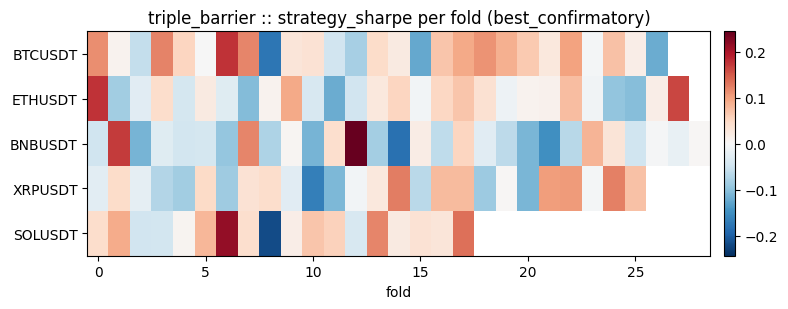

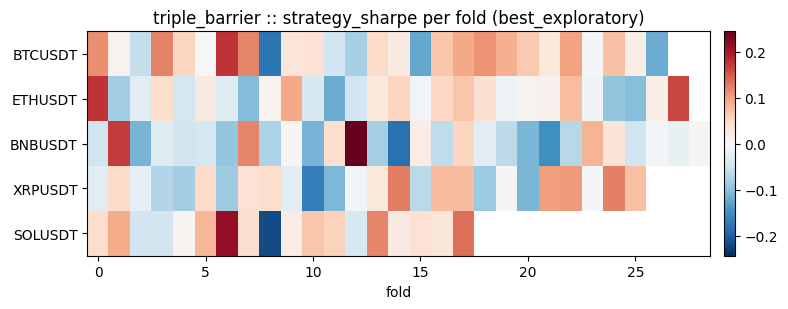

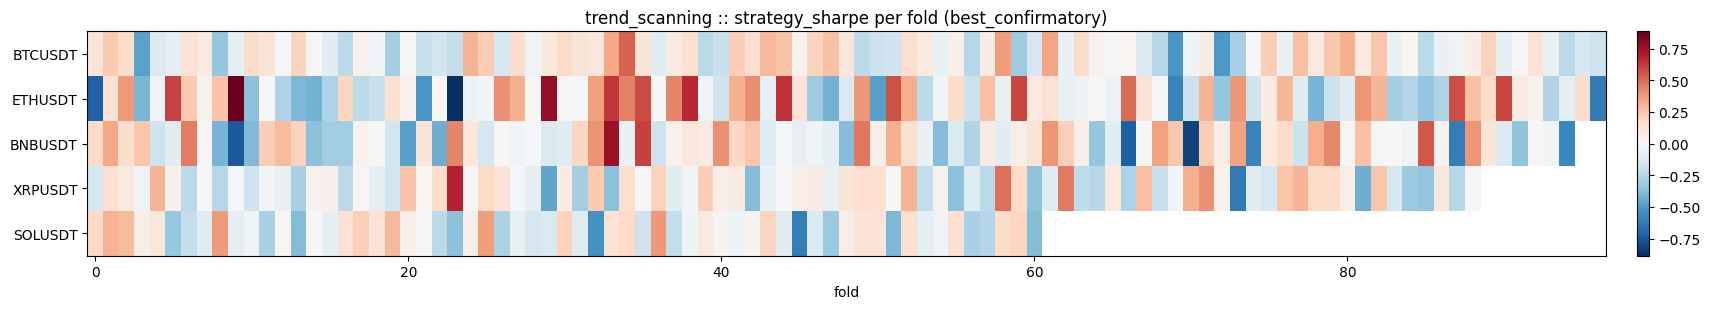

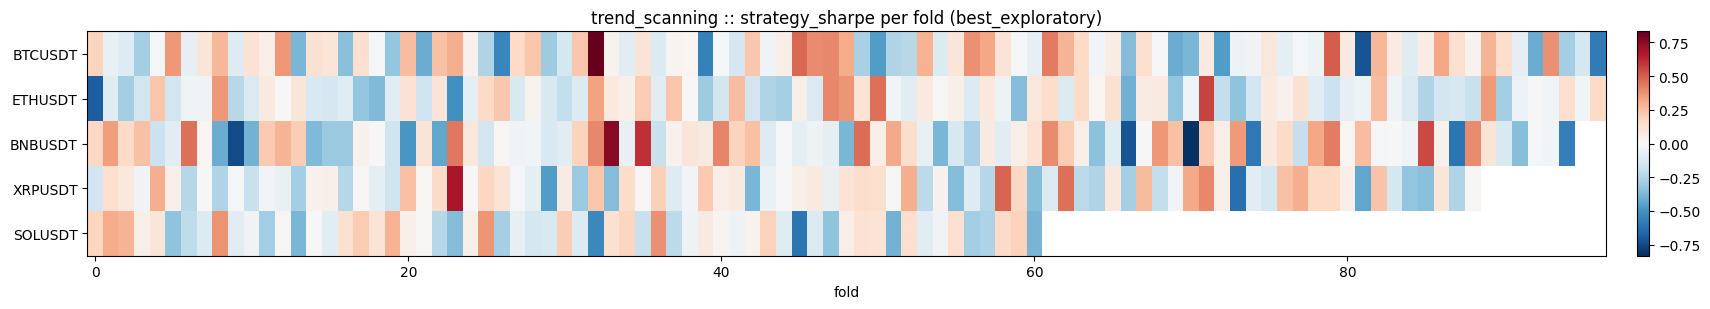

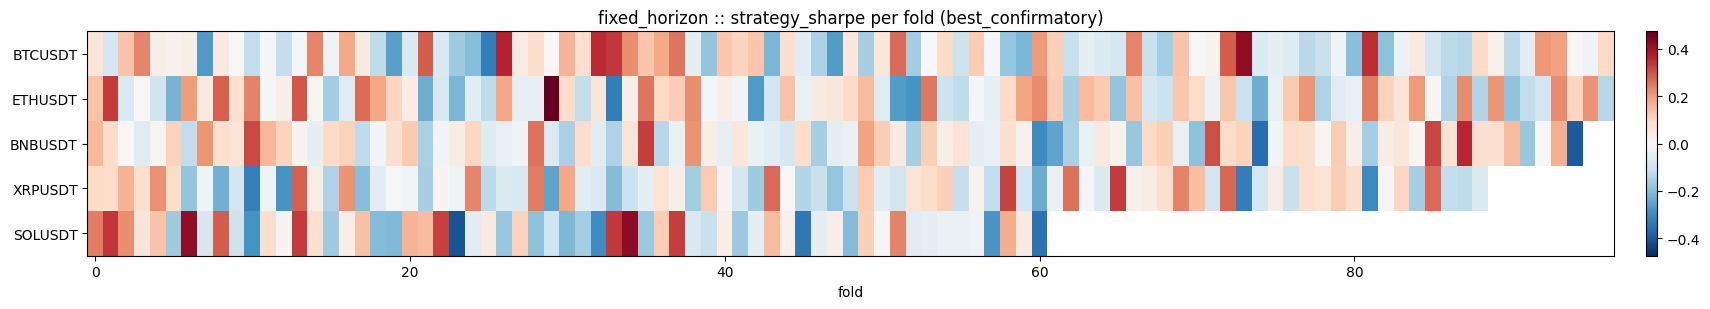

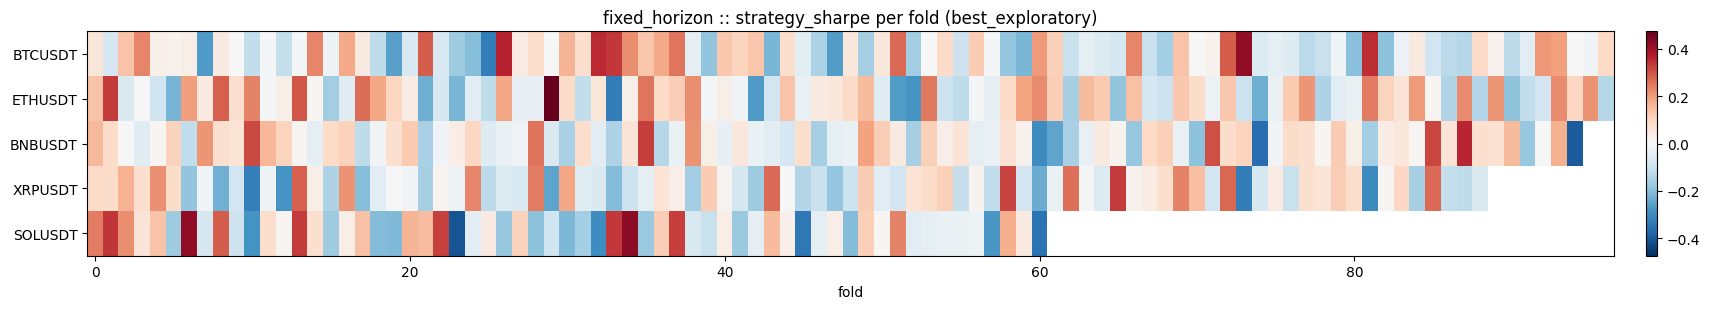

heatmaps -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/fold_sharpe_dispersion/heatmaps


In [6]:
def heatmap_for_method(method: str, definition: str = "best_confirmatory") -> None:
    rows = {}
    max_fold = -1
    for s in SYMBOLS:
        defs = best_definitions(load_summary(s, method))
        fam = defs.get(definition)
        if not fam:
            continue
        sub = fold_df[(fold_df.symbol == s) & (fold_df.method == method) & (fold_df.family == fam)].sort_values("fold")
        ser = sub.set_index("fold")["strategy_sharpe"]
        rows[s] = ser
        max_fold = max(max_fold, int(ser.index.max()) if len(ser) else -1)
    if not rows or max_fold < 0:
        return
    mat = pd.DataFrame(index=SYMBOLS, columns=range(max_fold + 1), dtype=float)
    for s, ser in rows.items():
        for f, v in ser.items():
            mat.loc[s, int(f)] = v
    fig, ax = plt.subplots(figsize=(max(8, max_fold * 0.18), 3.2))
    vmax = float(np.nanmax(np.abs(mat.values))) if mat.notna().any().any() else 1.0
    im = ax.imshow(mat.values.astype(float), aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(SYMBOLS)))
    ax.set_yticklabels(SYMBOLS)
    ax.set_xlabel("fold")
    ax.set_title(f"{method} :: strategy_sharpe per fold ({definition})")
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    fig.tight_layout()
    fig.savefig(FIG_DISP / "heatmaps" / f"{method}_{definition}.png", dpi=120)
    plt.show()


for method in METHODS:
    heatmap_for_method(method, "best_confirmatory")
    heatmap_for_method(method, "best_exploratory")
print("heatmaps ->", FIG_DISP / "heatmaps")


### A.4 Lineplots por (symbol, method) con las 4 definiciones

Una figura por símbolo (3 paneles, uno por method) mostrando la trayectoria de
`strategy_sharpe` a lo largo de folds para cada definición.


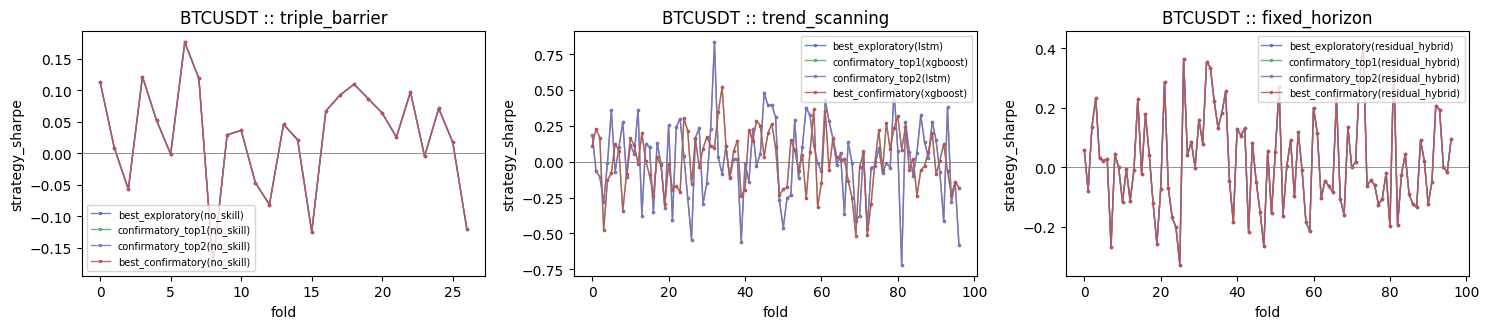

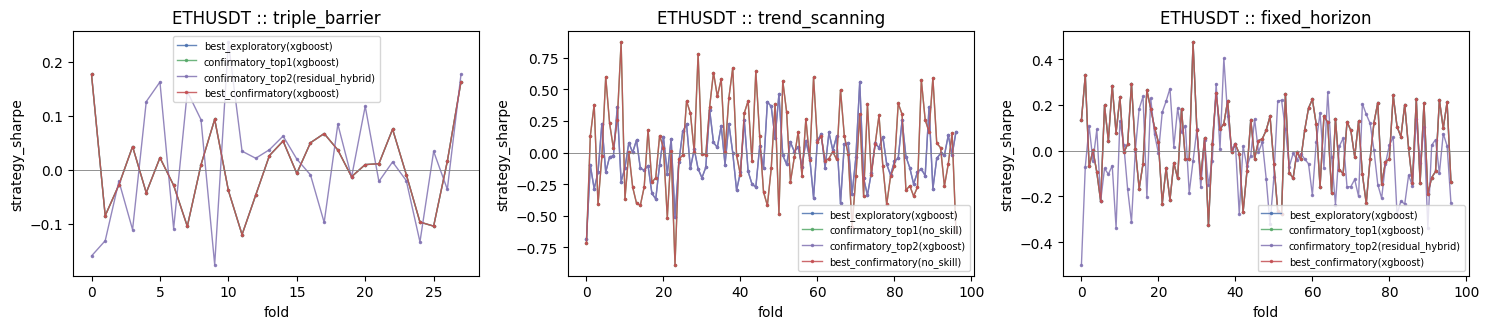

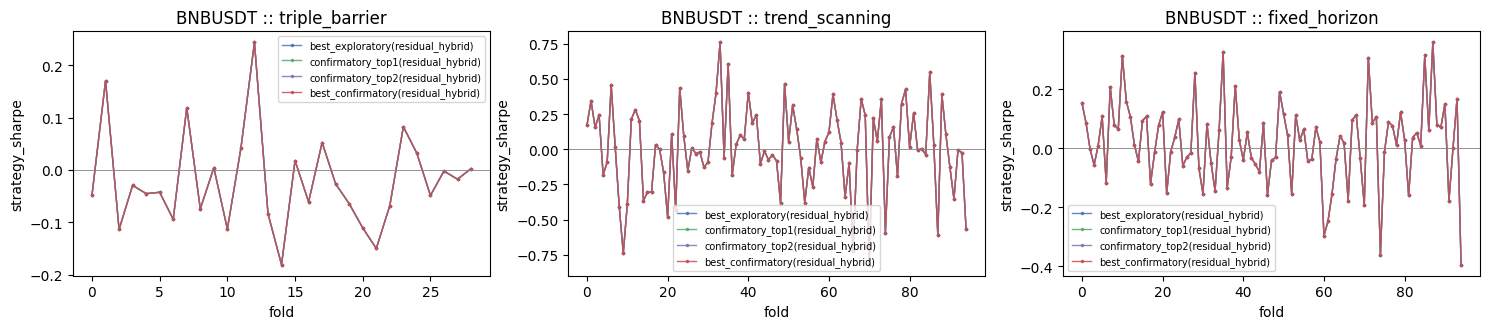

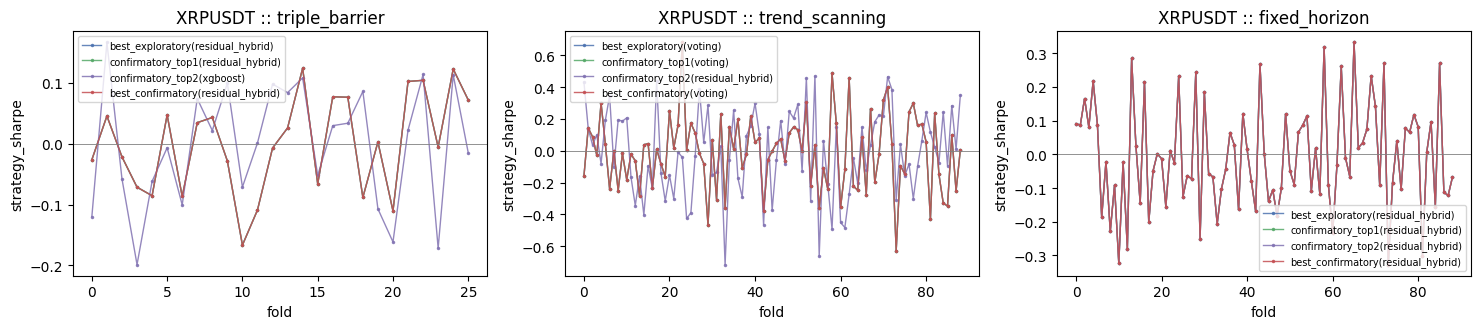

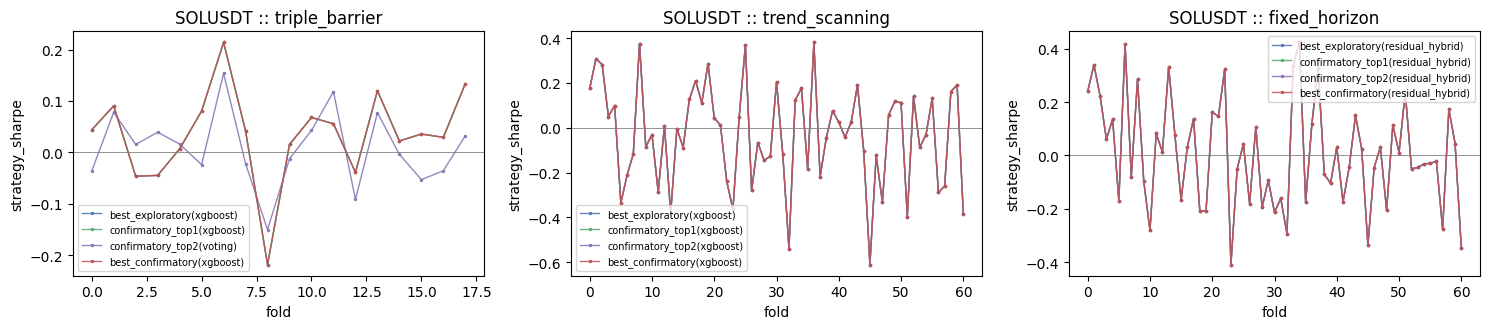

lineplots -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/fold_sharpe_dispersion/lineplots


In [7]:
DEF_COLORS = {
    "best_exploratory": "#4C72B0",
    "confirmatory_top1": "#55A868",
    "confirmatory_top2": "#8172B2",
    "best_confirmatory": "#C44E52",
}

for s in SYMBOLS:
    fig, axes = plt.subplots(1, len(METHODS), figsize=(15, 3.4), sharey=False)
    for ax, method in zip(axes, METHODS):
        defs = best_definitions(load_summary(s, method))
        plotted = False
        for definition in DEFINITIONS:
            fam = defs.get(definition)
            if not fam:
                continue
            sub = fold_df[(fold_df.symbol == s) & (fold_df.method == method) & (fold_df.family == fam)].sort_values("fold")
            if sub.empty:
                continue
            ax.plot(sub["fold"], sub["strategy_sharpe"], color=DEF_COLORS[definition], lw=1.0,
                    marker=".", ms=3, alpha=0.85, label=f"{definition}({fam})")
            plotted = True
        ax.axhline(0, color="gray", lw=0.6)
        ax.set_title(f"{s} :: {method}")
        ax.set_xlabel("fold")
        ax.set_ylabel("strategy_sharpe")
        if plotted:
            ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    fig.savefig(FIG_DISP / "lineplots" / f"{s}_sharpe_by_definition.png", dpi=120)
    plt.show()
print("lineplots ->", FIG_DISP / "lineplots")


### A.5 Test de Wilcoxon emparejado por fold entre definiciones

Cuando dos definiciones del mejor trial eligen **familias distintas**, comparamos sus
distribuciones de `strategy_sharpe` por fold con un Wilcoxon de rangos con signo
(emparejado por `fold_id`, ya que ambas familias se evalúan sobre el mismo walk-forward).

Comparaciones evaluadas por celda:

- `best_exploratory` vs `best_confirmatory`
- `confirmatory_top1` vs `confirmatory_top2`

Se reporta `n_pares`, mediana de la diferencia (`A - B`), estadístico, p-valor (two-sided)
y un veredicto a `alpha = 0.05`.

**Por qué hay tantos `NaN` en la tabla.** El Wilcoxon solo se ejecuta cuando las dos definiciones eligen familias **distintas** dentro de la misma celda. En este experimento, la mayoría de celdas coronan a la **misma familia** bajo todas las definiciones (o exploratorio y confirmatorio convergen), por lo que las filas se marcan en la columna `estado` (export CSV: `status`) como:

- `same_family` — A y B apuntan a la misma familia -> no hay nada que comparar.
- `missing_family` — alguna definición no produjo familia (p. ej. ranking incompleto).
- `no_paired_data` — sin folds emparejados disponibles.

En todos esos casos `n_pares`, `estadistico`, `p_valor` y `veredicto` aparecen como `NaN`/vacíos **por diseño**: no son fallos del cálculo, sino la señal de que la decisión es robusta frente a la regla de selección en esa celda. Solo las filas con `estado=ok` (CSV: `status=ok`) contienen test efectivo.


In [8]:
try:
    from scipy.stats import wilcoxon 
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False
    print("scipy no disponible: el test no se ejecutará; solo se reportarán medianas.")

WILCOXON_ALPHA = 0.05
COMPARISONS = [
    ("best_exploratory", "best_confirmatory"),
    ("confirmatory_top1", "confirmatory_top2"),
]


def paired_sharpes(symbol: str, method: str, family_a: str, family_b: str) -> pd.DataFrame:
    sub = fold_df[(fold_df.symbol == symbol) & (fold_df.method == method) & (fold_df.family.isin([family_a, family_b]))]
    pivot = sub.pivot_table(index="fold", columns="family", values="strategy_sharpe", aggfunc="first")
    pivot = pivot.dropna(subset=[family_a, family_b], how="any")
    return pivot


def wilcoxon_row(symbol: str, method: str, def_a: str, def_b: str) -> dict:
    defs = best_definitions(load_summary(symbol, method))
    fam_a, fam_b = defs.get(def_a), defs.get(def_b)
    base = {
        "symbol": symbol, "method": method,
        "definition_a": def_a, "family_a": fam_a,
        "definition_b": def_b, "family_b": fam_b,
    }
    if not fam_a or not fam_b:
        return {**base, "status": "missing_family", "n_pairs": 0}
    if fam_a == fam_b:
        return {**base, "status": "same_family", "n_pairs": 0}

    pivot = paired_sharpes(symbol, method, fam_a, fam_b)
    n = int(len(pivot))
    if n == 0:
        return {**base, "status": "no_paired_data", "n_pairs": 0}
    diff = pivot[fam_a] - pivot[fam_b]
    median_diff = float(diff.median())

    out = {**base, "status": "ok", "n_pairs": n,
           "median_diff_a_minus_b": round(median_diff, 4),
           "mean_diff_a_minus_b": round(float(diff.mean()), 4),
           "pct_pairs_a_gt_b": round(float((diff > 0).mean()), 4)}

    if not HAS_SCIPY:
        out["statistic"] = None
        out["p_value"] = None
        out["verdict"] = "scipy_unavailable"
        return out

    nonzero = diff[diff != 0]
    if len(nonzero) < 1:
        out["statistic"] = None
        out["p_value"] = None
        out["verdict"] = "all_diffs_zero"
        return out
    try:
        res = wilcoxon(diff.to_numpy(), zero_method="wilcox", alternative="two-sided", correction=False)
        stat = float(res.statistic)
        p = float(res.pvalue)
    except ValueError as e:
        out["statistic"] = None
        out["p_value"] = None
        out["verdict"] = f"wilcoxon_error:{e}"
        return out
    out["statistic"] = round(stat, 4)
    out["p_value"] = float(f"{p:.4g}")
    if p < WILCOXON_ALPHA:
        out["verdict"] = "A_better" if median_diff > 0 else ("B_better" if median_diff < 0 else "different_no_direction")
    else:
        out["verdict"] = "no_significant_difference"
    return out


wilcoxon_rows = []
for s in SYMBOLS:
    for m in METHODS:
        for da, db in COMPARISONS:
            wilcoxon_rows.append(wilcoxon_row(s, m, da, db))
wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df = wilcoxon_df[[
    "symbol", "method", "definition_a", "family_a", "definition_b", "family_b",
    "status", "n_pairs", "median_diff_a_minus_b", "mean_diff_a_minus_b",
    "pct_pairs_a_gt_b", "statistic", "p_value", "verdict",
]]
wilcoxon_df.sort_values(["method", "symbol", "definition_a"]).reset_index(drop=True).rename(columns=COLUMNAS_ES)


,simbolo,metodo,definicion_a,familia_a,definicion_b,familia_b,estado,n_pares,diff_mediana_a_menos_b,diff_media_a_menos_b,pct_pares_a_mayor_b,estadistico,p_valor,veredicto
0,BNBUSDT,fixed_horizon,best_exploratory,residual_hybrid,best_confirmatory,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
1,BNBUSDT,fixed_horizon,confirmatory_top1,residual_hybrid,confirmatory_top2,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
2,BTCUSDT,fixed_horizon,best_exploratory,residual_hybrid,best_confirmatory,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
3,BTCUSDT,fixed_horizon,confirmatory_top1,residual_hybrid,confirmatory_top2,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
4,ETHUSDT,fixed_horizon,best_exploratory,xgboost,best_confirmatory,xgboost,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
5,ETHUSDT,fixed_horizon,confirmatory_top1,xgboost,confirmatory_top2,residual_hybrid,ok,97,0.0460,0.0458,0.5979,1859.0,0.06259,no_significant_difference
6,SOLUSDT,fixed_horizon,best_exploratory,residual_hybrid,best_confirmatory,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
7,SOLUSDT,fixed_horizon,confirmatory_top1,residual_hybrid,confirmatory_top2,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
8,XRPUSDT,fixed_horizon,best_exploratory,residual_hybrid,best_confirmatory,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN
9,XRPUSDT,fixed_horizon,confirmatory_top1,residual_hybrid,confirmatory_top2,residual_hybrid,same_family,0,NaN,NaN,NaN,NaN,NaN,NaN


## B. Solape de clases y pesos entre métodos

Por símbolo se cargan `event_labels_4h.parquet` de triple barrera (TB), trend scanning (TS) y fixed horizon (FH). Sobre el índice común `event_start_ts` se comparan las parejas TB–TS, TB–FH y TS–FH: distribución de `label_side` (solape vs universo completo), pesos (`avg_uniqueness`, `sample_weight_overlap`, `concurrency`) y acuerdo simple/ponderado.


### B.1 Tabla de solape por celda `(simbolo, metodo_a, metodo_b)`

Una fila por celda. Las distribuciones de clase se expanden en columnas escalares (`_-1`, `_0`, `_1`) listas para exportar a CSV. La vista en pantalla renombra cabeceras al español; el CSV exportado conserva nombres en inglés (p. ej. `overlap_pct_of_a`, `agreement_pct`).

- `n_total_a` / `n_total_b`: eventos en el universo completo de cada método.
- `n_solape`, `pct_solape_sobre_a`, `pct_solape_sobre_b`: tamaño absoluto y relativo del solape.
- `dist_total_*_{-1,0,1}` / `dist_solape_*_{-1,0,1}`: proporción de clases en el universo completo y en el solape.
- `*_media_solape_*` / `*_p50_solape_*`: media y mediana de `avg_uniqueness`, `sample_weight_overlap` y `concurrency` dentro del solape, por método.
- `pct_acuerdo` y `acuerdo_ponderado_avg_uniqueness`: visualizados como heatmap en la sección B.4.

**Nota sobre por qué el solape es alto.** Los tres métodos comparten el mismo reloj de eventos CUSUM y solo difieren en cómo se etiqueta cada evento. Por tanto `pct_solape_sobre_a` y `pct_solape_sobre_b` son cercanos a 1 y `dist_total_*` ≈ `dist_solape_*`. El solape no es informativo en sí mismo: actúa como **denominador común** para comparar labels y pesos sobre los mismos instantes.

In [9]:
def labels_path(symbol: str, method: str) -> Path:
    if method == "triple_barrier":
        return TB_LABELS_ROOT / symbol / method / "event_labels_4h.parquet"
    return STD_LABELS_ROOT / symbol / method / "event_labels_4h.parquet"


def load_labels(symbol: str, method: str) -> pd.DataFrame:
    return pd.read_parquet(labels_path(symbol, method))


def class_distribution(series: pd.Series) -> dict:
    n = len(series)
    if n == 0:
        return {"-1": 0.0, "0": 0.0, "1": 0.0}
    counts = series.value_counts(dropna=False)
    return {str(k): round(float(counts.get(k, 0)) / n, 4) for k in (-1, 0, 1)}


PAIRS = [("triple_barrier", "trend_scanning"), ("triple_barrier", "fixed_horizon"), ("trend_scanning", "fixed_horizon")]
WEIGHT_COLS = ["avg_uniqueness", "sample_weight_overlap", "concurrency"]


def overlap_record(symbol: str, m_a: str, m_b: str) -> dict:
    a = load_labels(symbol, m_a).set_index("event_start_ts")
    b = load_labels(symbol, m_b).set_index("event_start_ts")
    common = a.index.intersection(b.index)
    a_o, b_o = a.loc[common], b.loc[common]
    rec = {
        "symbol": symbol,
        "method_a": m_a,
        "method_b": m_b,
        "n_full_a": int(len(a)),
        "n_full_b": int(len(b)),
        "n_overlap": int(len(common)),
        "overlap_pct_of_a": round(len(common) / max(len(a), 1), 4),
        "overlap_pct_of_b": round(len(common) / max(len(b), 1), 4),
    }
    rec["dist_full_a"] = class_distribution(a["label_side"])
    rec["dist_full_b"] = class_distribution(b["label_side"])
    rec["dist_overlap_a"] = class_distribution(a_o["label_side"])
    rec["dist_overlap_b"] = class_distribution(b_o["label_side"])
    if len(common):
        agree = float((a_o["label_side"] == b_o["label_side"]).mean())
        w = a_o["avg_uniqueness"].clip(lower=0).fillna(0)
        wsum = float(w.sum())
        weighted_agree = float(((a_o["label_side"] == b_o["label_side"]).astype(float) * w).sum() / wsum) if wsum > 0 else float("nan")
    else:
        agree = float("nan")
        weighted_agree = float("nan")
    rec["agreement_pct"] = round(agree, 4) if not np.isnan(agree) else None
    rec["weighted_agreement_avg_uniqueness"] = round(weighted_agree, 4) if not np.isnan(weighted_agree) else None
    for col in WEIGHT_COLS:
        for tag, df_o in (("a", a_o), ("b", b_o)):
            ser = df_o[col].dropna() if col in df_o.columns else pd.Series([], dtype=float)
            rec[f"{col}_mean_{tag}_overlap"] = round(float(ser.mean()), 4) if len(ser) else None
            rec[f"{col}_p50_{tag}_overlap"] = round(float(ser.median()), 4) if len(ser) else None
    return rec


overlap_rows = [overlap_record(s, ma, mb) for s in SYMBOLS for ma, mb in PAIRS]

def flatten_dist_columns(rec: dict) -> dict:
    out = {k: v for k, v in rec.items() if not isinstance(v, dict)}
    for prefix in ("dist_full_a", "dist_full_b", "dist_overlap_a", "dist_overlap_b"):
        d = rec.get(prefix, {}) or {}
        for k in ("-1", "0", "1"):
            out[f"{prefix}_{k}"] = d.get(k)
    return out


overlap_flat = pd.DataFrame([flatten_dist_columns(r) for r in overlap_rows])
overlap_flat.sort_values(["method_a", "method_b", "symbol"]).reset_index(drop=True).rename(columns=COLUMNAS_ES)


,simbolo,metodo_a,metodo_b,n_total_a,n_total_b,n_solape,pct_solape_sobre_a,pct_solape_sobre_b,pct_acuerdo,acuerdo_ponderado_avg_uniqueness,avg_uniqueness_media_solape_a,avg_uniqueness_p50_solape_a,avg_uniqueness_media_solape_b,avg_uniqueness_p50_solape_b,sample_weight_overlap_media_solape_a,sample_weight_overlap_p50_solape_a,sample_weight_overlap_media_solape_b,sample_weight_overlap_p50_solape_b,concurrency_media_solape_a,concurrency_p50_solape_a,concurrency_media_solape_b,concurrency_p50_solape_b,dist_total_a_-1,dist_total_a_0,dist_total_a_1,dist_total_b_-1,dist_total_b_0,dist_total_b_1,dist_solape_a_-1,dist_solape_a_0,dist_solape_a_1,dist_solape_b_-1,dist_solape_b_0,dist_solape_b_1
0,BNBUSDT,trend_scanning,fixed_horizon,18256,18274,18256,1.0,0.9990,0.6168,0.6004,0.0681,0.0631,0.1429,0.1429,0.0681,0.0631,0.1429,0.1429,19.9924,21.0,7.0000,7.0,0.4635,0.0057,0.5308,0.4005,0.1629,0.4366,0.4635,0.0057,0.5308,0.4005,0.1630,0.4366
1,BTCUSDT,trend_scanning,fixed_horizon,18826,18844,18826,1.0,0.9990,0.5816,0.5641,0.0657,0.0610,0.1429,0.1429,0.0657,0.0610,0.1429,0.1429,20.5604,22.0,7.0000,7.0,0.4636,0.0067,0.5296,0.3760,0.2103,0.4137,0.4636,0.0067,0.5296,0.3759,0.2104,0.4137
2,ETHUSDT,trend_scanning,fixed_horizon,18741,18759,18741,1.0,0.9990,0.6210,0.6040,0.0672,0.0628,0.1429,0.1429,0.0672,0.0628,0.1429,0.1429,20.1756,21.0,7.0000,7.0,0.4732,0.0053,0.5215,0.4082,0.1536,0.4382,0.4732,0.0053,0.5215,0.4083,0.1536,0.4381
3,SOLUSDT,trend_scanning,fixed_horizon,12201,12219,12201,1.0,0.9985,0.6615,0.6477,0.0674,0.0631,0.1429,0.1429,0.0674,0.0631,0.1429,0.1429,20.0766,21.0,7.0000,7.0,0.5029,0.0032,0.4939,0.4597,0.0945,0.4458,0.5029,0.0032,0.4939,0.4598,0.0945,0.4457
4,XRPUSDT,trend_scanning,fixed_horizon,17180,17198,17180,1.0,0.9990,0.6176,0.6027,0.0681,0.0636,0.1429,0.1429,0.0681,0.0636,0.1429,0.1429,20.0386,21.0,7.0000,7.0,0.5214,0.0065,0.4721,0.4373,0.1498,0.4129,0.5214,0.0065,0.4721,0.4374,0.1497,0.4129
5,BNBUSDT,triple_barrier,fixed_horizon,6440,18274,6440,1.0,0.3524,0.7835,0.7756,0.5529,0.5000,0.1429,0.1429,0.5529,0.5000,0.1429,0.1429,2.7185,3.0,7.0000,7.0,0.4871,0.0000,0.5129,0.4005,0.1629,0.4366,0.4871,0.0000,0.5129,0.3981,0.1430,0.4589
6,BTCUSDT,triple_barrier,fixed_horizon,6063,18844,6063,1.0,0.3217,0.7561,0.7424,0.5814,0.5476,0.1429,0.1429,0.5814,0.5476,0.1429,0.1429,2.6343,3.0,7.0000,7.0,0.4808,0.0000,0.5192,0.3760,0.2103,0.4137,0.4808,0.0000,0.5192,0.3855,0.1762,0.4384
7,ETHUSDT,triple_barrier,fixed_horizon,6290,18759,6290,1.0,0.3353,0.7952,0.7870,0.5729,0.5238,0.1429,0.1429,0.5729,0.5238,0.1429,0.1429,2.6593,3.0,7.0000,7.0,0.4928,0.0000,0.5072,0.4082,0.1536,0.4382,0.4928,0.0000,0.5072,0.4151,0.1261,0.4588
8,SOLUSDT,triple_barrier,fixed_horizon,4481,12219,4481,1.0,0.3667,0.8275,0.8211,0.5390,0.5000,0.1429,0.1429,0.5390,0.5000,0.1429,0.1429,2.7806,3.0,7.0000,7.0,0.4979,0.0000,0.5021,0.4597,0.0945,0.4458,0.4979,0.0000,0.5021,0.4526,0.0828,0.4646
9,XRPUSDT,triple_barrier,fixed_horizon,5772,17198,5772,1.0,0.3356,0.7907,0.7839,0.5738,0.5333,0.1429,0.1429,0.5738,0.5333,0.1429,0.1429,2.6611,3.0,7.0000,7.0,0.5120,0.0000,0.4880,0.4373,0.1498,0.4129,0.5120,0.0000,0.4880,0.4361,0.1301,0.4338


### B.2 Figuras: distribución de clases full vs. overlap por par

Por símbolo y par, barras agrupadas {-1, 0, 1} comparando full vs overlap para los dos
métodos del par.


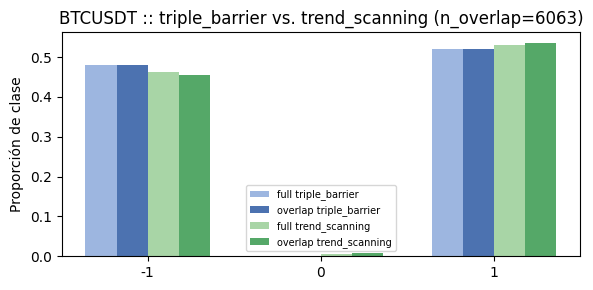

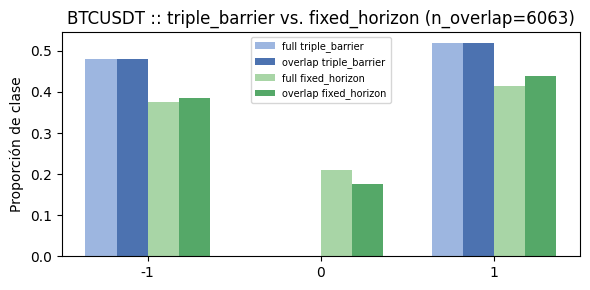

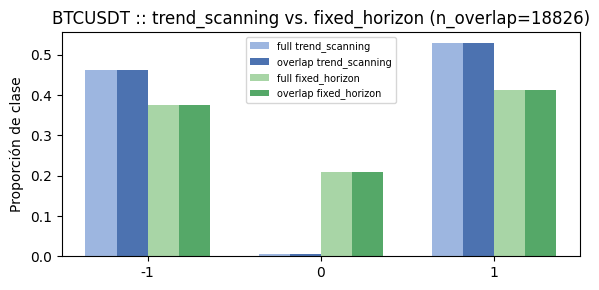

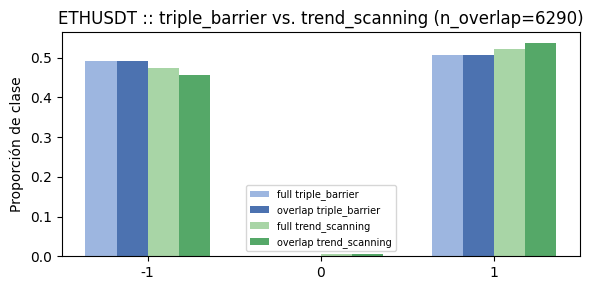

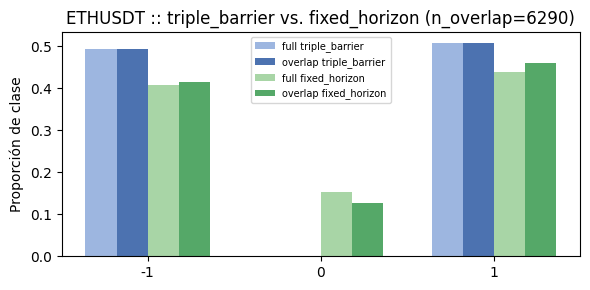

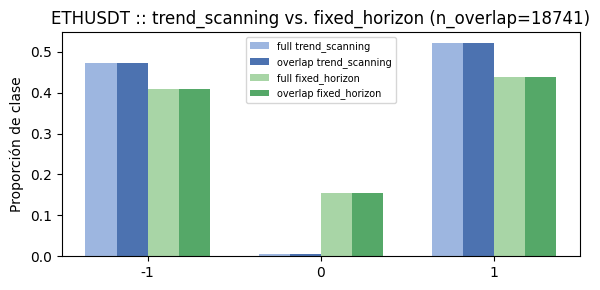

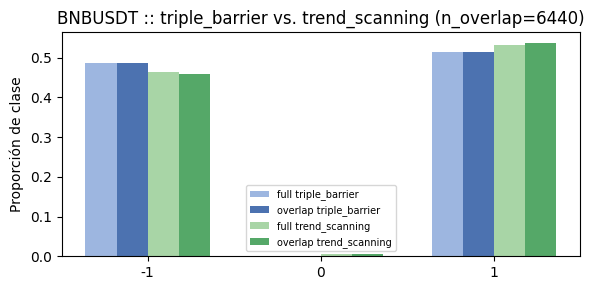

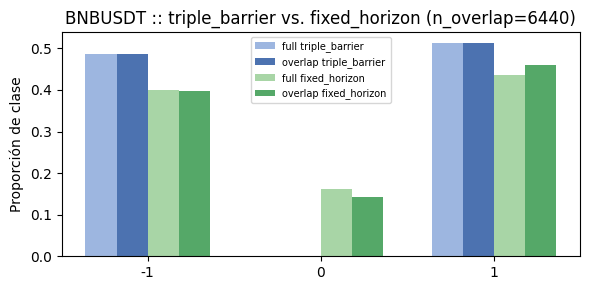

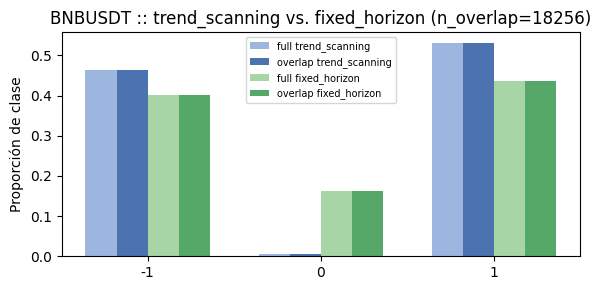

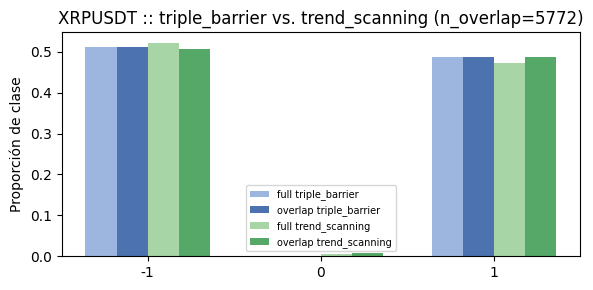

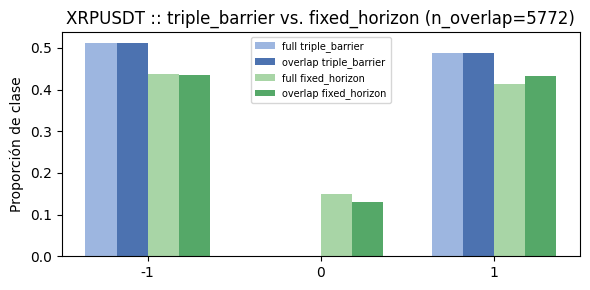

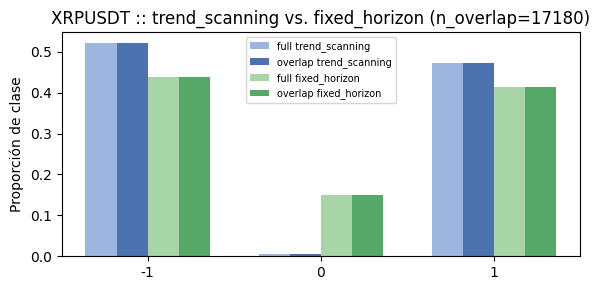

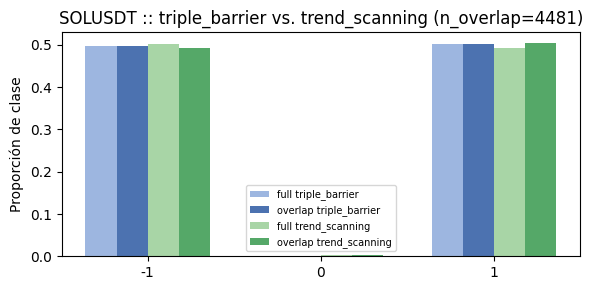

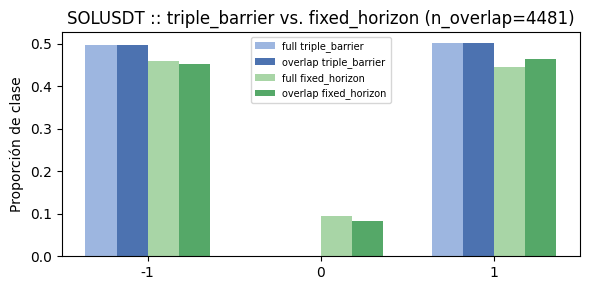

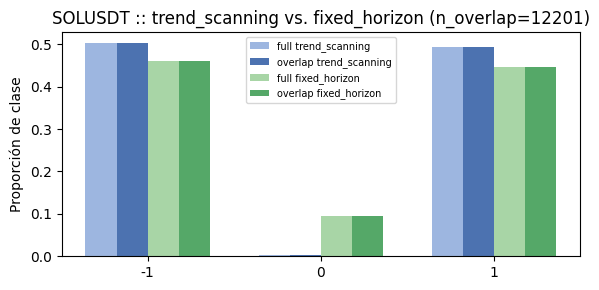

class distribution figs -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/label_overlap/class_distribution


In [10]:
def plot_class_dist_full_vs_overlap(rec: dict) -> None:
    classes = ["-1", "0", "1"]
    x = np.arange(len(classes))
    width = 0.18
    full_a = [rec["dist_full_a"].get(c, 0.0) for c in classes]
    full_b = [rec["dist_full_b"].get(c, 0.0) for c in classes]
    over_a = [rec["dist_overlap_a"].get(c, 0.0) for c in classes]
    over_b = [rec["dist_overlap_b"].get(c, 0.0) for c in classes]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(x - 1.5 * width, full_a, width, label=f"full {rec['method_a']}", color="#9DB6E0")
    ax.bar(x - 0.5 * width, over_a, width, label=f"overlap {rec['method_a']}", color="#4C72B0")
    ax.bar(x + 0.5 * width, full_b, width, label=f"full {rec['method_b']}", color="#A8D5A6")
    ax.bar(x + 1.5 * width, over_b, width, label=f"overlap {rec['method_b']}", color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylabel("Proporción de clase")
    ax.set_title(f"{rec['symbol']} :: {rec['method_a']} vs. {rec['method_b']} (n_overlap={rec['n_overlap']})")
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    pair_tag = f"{rec['method_a']}__vs__{rec['method_b']}"
    fig.savefig(FIG_OVER / "class_distribution" / f"{rec['symbol']}_{pair_tag}.png", dpi=120)
    plt.show()


for rec in overlap_rows:
    plot_class_dist_full_vs_overlap(rec)
print("class distribution figs ->", FIG_OVER / "class_distribution")


### B.3 Figuras: histogramas de `avg_uniqueness` (universo completo vs. solape)

Una figura por símbolo, con un panel por método. Cada panel superpone el histograma de `avg_uniqueness` sobre el universo completo y sobre cada intersección con los otros dos métodos.


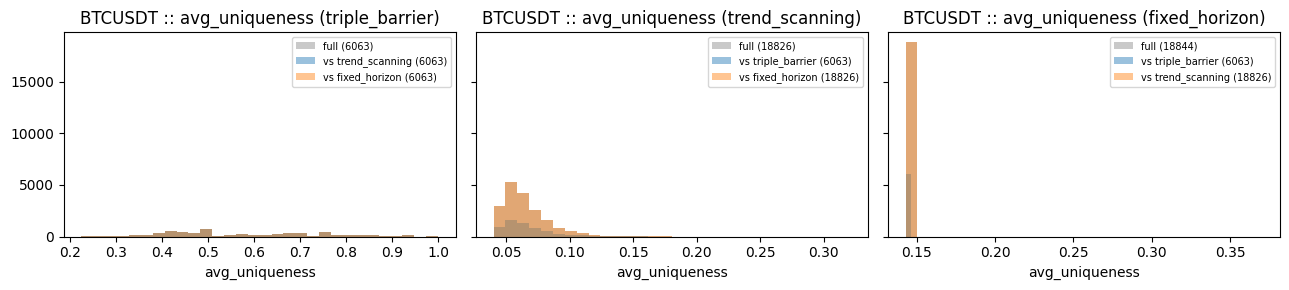

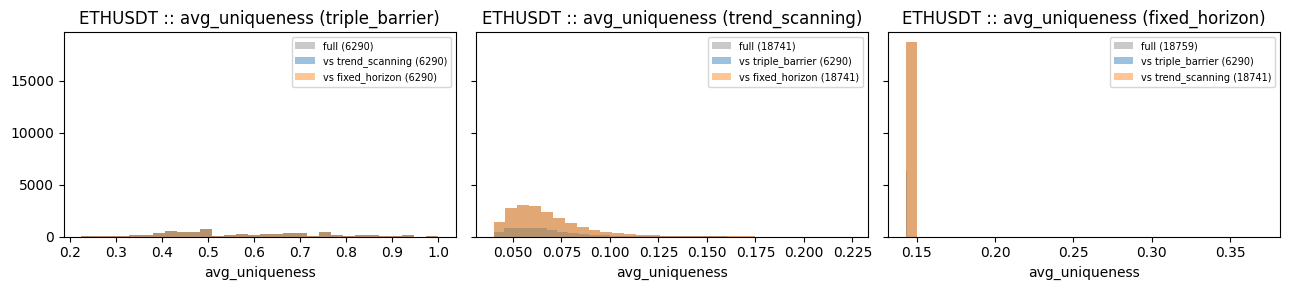

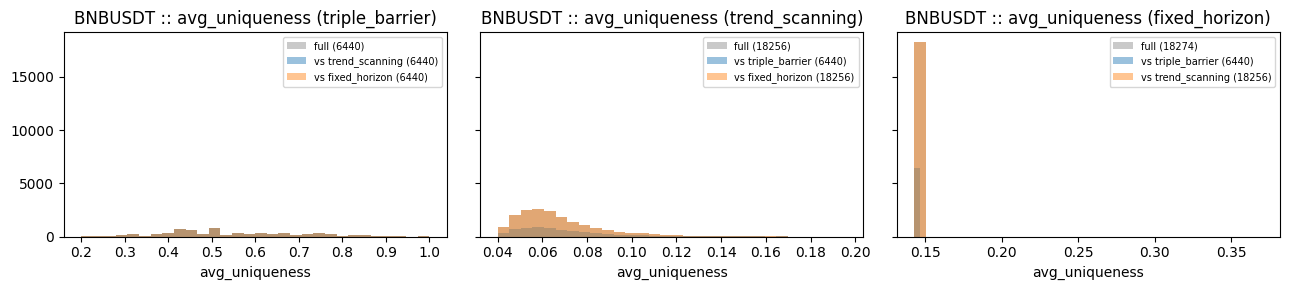

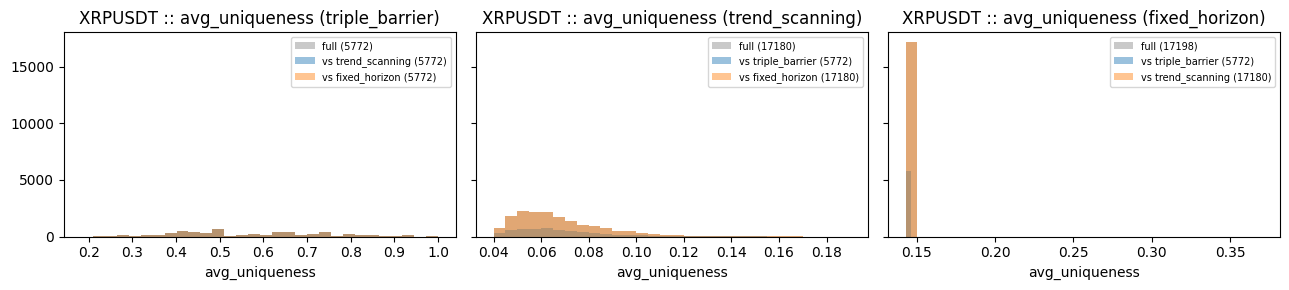

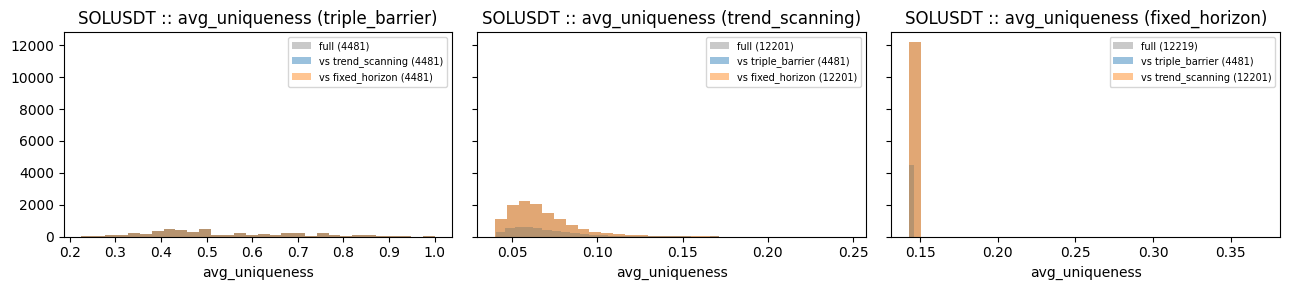

weights figs -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/label_overlap/weights


In [11]:
def plot_uniqueness_full_vs_overlap(symbol: str) -> None:
    fig, axes = plt.subplots(1, len(METHODS), figsize=(13, 3), sharey=True)
    full_dfs = {m: load_labels(symbol, m).set_index("event_start_ts") for m in METHODS}
    for ax, m in zip(axes, METHODS):
        full_u = full_dfs[m]["avg_uniqueness"].dropna()
        ax.hist(full_u, bins=30, alpha=0.45, color="#888888", label=f"full ({len(full_u)})")
        for other in METHODS:
            if other == m:
                continue
            common = full_dfs[m].index.intersection(full_dfs[other].index)
            o = full_dfs[m].loc[common, "avg_uniqueness"].dropna()
            if len(o):
                ax.hist(o, bins=30, alpha=0.45, label=f"vs {other} ({len(o)})")
        ax.set_title(f"{symbol} :: avg_uniqueness ({m})")
        ax.set_xlabel("avg_uniqueness")
        ax.legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(FIG_OVER / "weights" / f"{symbol}_avg_uniqueness.png", dpi=120)
    plt.show()


for s in SYMBOLS:
    plot_uniqueness_full_vs_overlap(s)
print("weights figs ->", FIG_OVER / "weights")


`avg_uniqueness` (AFML) mide cuán único es un label dentro de su horizonte: 1.0 = no comparte ventana con ningún otro evento; cercano a 0 = pesos efectivos bajos por solapamiento temporal.

- Curvas `full` y `overlap` superpuestas -> restringir al solape no introduce sesgo de unicidad.
- Curva `overlap` desplazada a la izquierda -> los eventos comunes están más solapados; la comparación parte de pesos efectivos menores.
- Diferencias entre paneles -> reflejan la naturaleza del método (TB con barreras, TS con ventanas adaptativas, FH con horizonte fijo).


### B.4 Acuerdo simple vs. ponderado por `avg_uniqueness`

Dos heatmaps símbolo × par. Izquierda: `pct_acuerdo` (fracción de eventos del solape con la misma `label_side`). Derecha: `acuerdo_ponderado_avg_uniqueness` (mismo cálculo ponderando cada evento por su `avg_uniqueness` del método A).


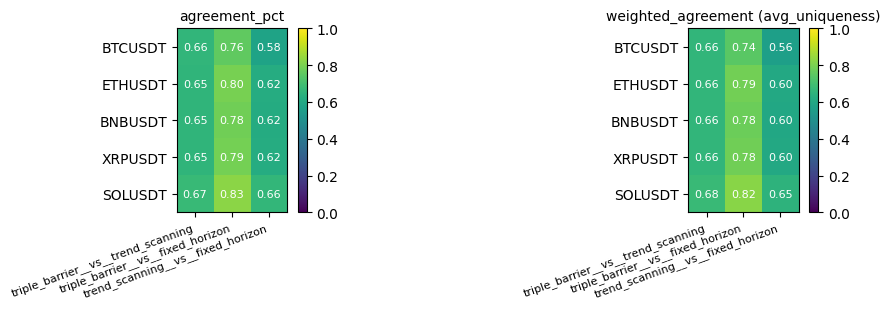

agreement fig -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/figures/label_overlap/agreement


In [12]:
pair_labels = [f"{a}__vs__{b}" for a, b in PAIRS]
agree_mat = np.zeros((len(SYMBOLS), len(PAIRS)))
wagree_mat = np.zeros((len(SYMBOLS), len(PAIRS)))
for i, s in enumerate(SYMBOLS):
    for j, (ma, mb) in enumerate(PAIRS):
        rec = next(r for r in overlap_rows if r["symbol"] == s and r["method_a"] == ma and r["method_b"] == mb)
        agree_mat[i, j] = rec["agreement_pct"] or np.nan
        wagree_mat[i, j] = rec["weighted_agreement_avg_uniqueness"] or np.nan

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, mat, title in zip(axes, [agree_mat, wagree_mat], ["agreement_pct", "weighted_agreement (avg_uniqueness)"]):
    im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(PAIRS)))
    ax.set_xticklabels(pair_labels, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(range(len(SYMBOLS)))
    ax.set_yticklabels(SYMBOLS)
    ax.set_title(title, fontsize=10)
    for i in range(len(SYMBOLS)):
        for j in range(len(PAIRS)):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout()
fig.savefig(FIG_OVER / "agreement" / "agreement_simple_vs_weighted.png", dpi=120)
plt.show()
print("agreement fig ->", FIG_OVER / "agreement")


- Valores altos -> los dos métodos asignan la misma clase en el solape; el desacuerdo no explica diferencias de modelado.
- Valores bajos -> discrepancia sistemática en `label_side`; comparar modelos entre TB/TS/FH en esa celda equivale a comparar targets distintos.
- Ponderado **mayor** que el simple -> los desacuerdos caen sobre eventos de baja unicidad (ruido temporal); ponderado **menor** -> los desacuerdos pesan sobre eventos limpios y son metodológicamente más severos.


## Conclusiones

**Sobre la robustez del campeón (sección A).**

- El Sharpe del campeón **no es estable fold a fold**: la `sharpe_iqr` y el `pct_folds_sharpe_pos` muestran que en varias celdas el rendimiento agregado convive con folds claramente negativos. El número de cierre de `01_evidencia_shortlist_baseline.ipynb` (Sharpe agregado OOS) debe leerse acompañado de esta dispersión.
- Las cuatro reglas de selección del campeón (`best_exploratory`, `confirmatory_top1/2`, `best_confirmatory`) tienden a **converger en la misma familia** dentro de cada celda. Esto es lo que produce la mayoría de `NaN` en el Wilcoxon (estado `same_family`) y, leído al revés, es una **señal positiva**: la decisión confirmatoria no depende críticamente del criterio de desempate usado.
- En las pocas celdas donde sí hay familias distintas, el Wilcoxon pareado por fold permite cuantificar si la diferencia entre definiciones es estadísticamente relevante o ruido fold-level. El veredicto debe interpretarse junto al `n_pairs` (test poco potente con pocos folds) y al signo de `median_diff_a_minus_b`.

**Sobre el solape de etiquetas entre métodos (sección B).**

- TB, TS y FH comparten el mismo reloj de eventos (CUSUM), por lo que `pct_solape_sobre_a` y `pct_solape_sobre_b` son altos y `dist_total_*` ≈ `dist_solape_*`. El solape no aporta novedad: sirve como **denominador común** para comparar etiquetas y pesos sobre los mismos eventos.
- Los histogramas de `avg_uniqueness` (B.3) muestran que restringir al solape **no sesga** la distribución de pesos respecto al universo natural de cada método; por tanto las comparaciones entre métodos sobre eventos comunes son metodológicamente válidas.
- El acuerdo simple vs. ponderado (B.4) indica que, aun compartiendo eventos, los tres métodos **discrepan en la clase asignada** en una fracción no trivial de casos. Esa discrepancia es parte de las diferencias observadas en `01_evidencia_shortlist_baseline.ipynb` entre celdas (BTC-TB, BTC-TS, BTC-FH, …): no todo es "qué modelo gana", también es "qué target se está modelando".

**Implicaciones**

- El veredicto de Exp1 de `01_evidencia_shortlist_baseline.ipynb` se sostiene: este complemento **no invalida** ninguna decisión, pero aporta el matiz de que la elección de familia es **robusta a la regla de selección** y de que las diferencias entre métodos de etiquetado son, en parte, diferencias de target y no solo de modelo.
- Para citar en memoria: usar `baseline_shortlist_fold_definition_summary.csv` para estabilidad fold-level, `baseline_shortlist_fold_wilcoxon_comparisons.csv` (filas `status=ok`) para robustez de la regla de campeón, y `figures/label_overlap/agreement/agreement_simple_vs_weighted.png` para enmarcar las diferencias TB/TS/FH como diferencias de etiquetado, no solo de aprendizaje.

**Artefactos exportados** (manifest `reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/`):

- Tablas CSV en `tables/`:
  - `baseline_shortlist_fold_definition_summary.csv`
  - `baseline_shortlist_fold_wilcoxon_comparisons.csv`
  - `baseline_shortlist_label_overlap_summary.csv`
- Figuras en `figures/fold_sharpe_dispersion/`: `boxplots/` (3 PNG), `heatmaps/` (6 PNG: `best_confirmatory` y `best_exploratory` por method), `lineplots/` (5 PNG por símbolo).
- Figuras en `figures/label_overlap/`: `class_distribution/` (15 PNG), `weights/` (5 PNG), `agreement/agreement_simple_vs_weighted.png`.


In [13]:
definition_summary_df.to_csv(TABLE_DIR / "baseline_shortlist_fold_definition_summary.csv", index=False)
wilcoxon_df.to_csv(TABLE_DIR / "baseline_shortlist_fold_wilcoxon_comparisons.csv", index=False)
overlap_flat.to_csv(TABLE_DIR / "baseline_shortlist_label_overlap_summary.csv", index=False)
print("tablas exportadas ->", TABLE_DIR)


tablas exportadas -> /app/reports/validation/experiments/baseline_shortlist_20260502T120458Z_evidence/tables
